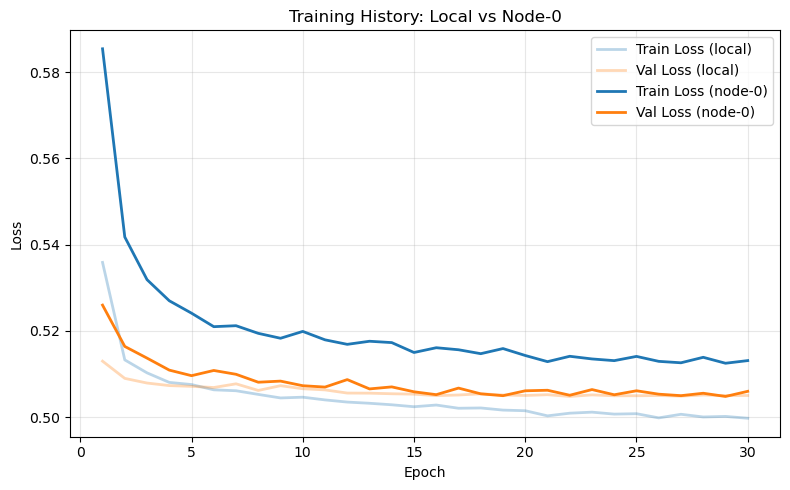

In [8]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load main history.json (dimmed)
with open("history.json", "r") as f:
    history = json.load(f)
df = pd.DataFrame(history)

# Load node-0 history
with open("history_node-0.json", "r") as f:
    history_node0 = json.load(f)
df_node0 = pd.DataFrame(history_node0)

fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot dimmed main history
ax1.plot(df["epoch"], df["train_loss"], label="Train Loss (local)", linewidth=2, color="C0", alpha=0.3)
ax1.plot(df["epoch"], df["val_loss"], label="Val Loss (local)", linewidth=2, color="C1", alpha=0.3)

# Plot node-0 history
ax1.plot(df_node0["epoch"], df_node0["train_loss"], label="Train Loss (node-0)", linewidth=2, color="C0")
ax1.plot(df_node0["epoch"], df_node0["val_loss"], label="Val Loss (node-0)", linewidth=2, color="C1")

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right")

plt.title("Training History: Local vs Node-0")
fig.tight_layout()
plt.show()

In [4]:
import re
import pandas as pd

def parse_eval_log_to_df(path: str, default_node: str | None = None) -> pd.DataFrame:
    """
    Parse a log text file containing a classification report and return a DataFrame with:
    accuracy, roc_auc, and precision/recall/f1 for classes 0 and 1.

    If no 'node-X' header is found, uses default_node.
    """
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()

    rows = []

    # Try to find explicit node headers
    node_headers = list(re.finditer(r"^node-\d+\s*$", text, flags=re.MULTILINE))

    blocks = []
    if node_headers:
        # Split by node headers (keep header with block)
        starts = [m.start() for m in node_headers] + [len(text)]
        for i in range(len(starts) - 1):
            blocks.append(text[starts[i]:starts[i + 1]])
    else:
        # Single block, no node header
        blocks = [text]

    for b in blocks:
        # Node name
        node_m = re.search(r"^(node-\d+)\s*$", b, flags=re.MULTILINE)
        node = node_m.group(1) if node_m else default_node

        acc_m = re.search(r"Accuracy:\s*([0-9]*\.?[0-9]+)", b)
        auc_m = re.search(r"ROC-AUC:\s*([0-9]*\.?[0-9]+)", b)

        c0_m = re.search(
            r"^\s*0\s+([0-9]*\.?[0-9]+)\s+([0-9]*\.?[0-9]+)\s+([0-9]*\.?[0-9]+)\s+\d+\s*$",
            b,
            flags=re.MULTILINE,
        )
        c1_m = re.search(
            r"^\s*1\s+([0-9]*\.?[0-9]+)\s+([0-9]*\.?[0-9]+)\s+([0-9]*\.?[0-9]+)\s+\d+\s*$",
            b,
            flags=re.MULTILINE,
        )

        row = {"node": node}

        row["accuracy"] = float(acc_m.group(1)) if acc_m else None
        row["roc_auc"] = float(auc_m.group(1)) if auc_m else None

        if c0_m:
            row["precision_0"] = float(c0_m.group(1))
            row["recall_0"] = float(c0_m.group(2))
            row["f1_0"] = float(c0_m.group(3))
        else:
            row["precision_0"] = row["recall_0"] = row["f1_0"] = None

        if c1_m:
            row["precision_1"] = float(c1_m.group(1))
            row["recall_1"] = float(c1_m.group(2))
            row["f1_1"] = float(c1_m.group(3))
        else:
            row["precision_1"] = row["recall_1"] = row["f1_1"] = None

        rows.append(row)

    return pd.DataFrame(rows)


In [7]:
df_global = parse_eval_log_to_df(
    "classification_report.txt",
    default_node="local"
)

df_node2 = parse_eval_log_to_df(
    "classification_report_node-0.txt",
    default_node="node-2"
)

df_global["source"] = "local"
df_node2["source"] = "node-1"

df_all = pd.concat([df_global, df_node2], ignore_index=True)

df_all


,node,accuracy,roc_auc,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,source
0,local,0.729659,0.830147,0.96,0.72,0.82,0.31,0.79,0.45,local
1,node-0,0.726118,0.834972,0.96,0.72,0.82,0.31,0.80,0.45,node-1


In [16]:
import sys
import os

# Add project root to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import torch
import pandas as pd
from model.train_local import MLP, to_tensor_dataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import numpy as np

# --- Load test data as in train_local.py ---
data_path = "/home/duje/diplomski-projekt/data/diabetes_binary_health_indicators_BRFSS2015.csv"
df = pd.read_csv(data_path)
X = df.drop(columns=["Diabetes_binary"]).copy()
y = df[["Diabetes_binary"]].copy()

continuous_cols = ["BMI", "Age", "Income"]
scaler = StandardScaler()
X[continuous_cols] = scaler.fit_transform(X[continuous_cols])

# Use the same splits as train_local.py (seed=42)
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# --- Load node-2 model ---
input_dim = X_train.shape[1]
model = MLP(input_dim)
ckpt = torch.load("node-2_epoch_030.pt", map_location="cpu")
if "state_dict" in ckpt:
    model.load_state_dict(ckpt["state_dict"])
else:
    model.load_state_dict(ckpt)
model.eval()

# --- Predict on test set ---
import torch.nn as nn
from torch.utils.data import DataLoader

test_ds = to_tensor_dataset(X_test, y_test)
test_dl = DataLoader(test_ds, batch_size=1024, shuffle=False)

all_probs = []
all_y = []
softmax = nn.Softmax(dim=1)
for xb, yb in test_dl:
    logits = model(xb)
    probs = softmax(logits)[:, 1].detach().cpu().numpy()
    all_probs.append(probs)
    all_y.append(yb.numpy())
y_proba_test = np.concatenate(all_probs)
y_true_test = np.concatenate(all_y)

# Use the same threshold as in metrics_node-0.json
threshold = 0.52
y_pred_test = (y_proba_test >= threshold).astype(int)

# --- Display classification report ---
print(classification_report(y_true_test, y_pred_test, digits=4))

              precision    recall  f1-score   support

           0     0.9541    0.7248    0.8238     32750
           1     0.3158    0.7844    0.4503      5302

    accuracy                         0.7331     38052
   macro avg     0.6349    0.7546    0.6370     38052
weighted avg     0.8651    0.7331    0.7717     38052

